In [ ]:
# 1 Importing libraries for functions
import requests
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [ ]:
# 2 All Lists used in the code
team_ids = [
    108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
    133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 158
]
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}

# Master DataFrames
all_standard = []
all_statcast = []

# Statcast features and betas
hit_features = ['Whiff %','Batted Balls','Hard Hit %','Exit Velocity','XBA','Zone Contact %','Chase %', 'Zone Swing %', 'Straight %']
walk_features = ['Chase %', 'Batted Balls', 'Pitches', 'Whiff %', 'Zone Swing %', 'Zone Contact %']
bats_features = ['Pitches', 'Batted Balls']
bases_features = ['XSLG','Whiff %','Chase %','Barrel %', 'Hard Hit %', 'Exit Velocity', 'Launch Angle', 'Straight %', 'Batted Balls']

hit_betas = {'Whiff %': .6,'Batted Balls': .8,'Hard Hit %': 1,'Exit Velocity': .7,'XBA': .9,'Zone Contact %': .3,'Chase %': .5, 'Zone Swing %': .2, 'Straight %': .4}
walk_betas = {'Chase %': .5, 'Batted Balls': 1, 'Pitches': .8, 'Whiff %': .5, 'Zone Swing %': .1, 'Zone Contact %': .2}
bats_betas = {'Pitches': .3, 'Batted Balls': .7}
bases_betas = {'XSLG': .9,'Whiff %': .5,'Chase %': .5,'Barrel %': 1, 'Hard Hit %': .8, 'Exit Velocity': .7, 'Launch Angle': .3, 'Straight %': .4, 'Batted Balls': .3}

unwanted = ['Unnamed: 1_level_0', 'Unnamed: 0_level_0', 'Statcast', 'Standard Stats','Unnamed: 26_level_1']

In [ ]:
# 3 Fetching the data
def clean_column(col):
    for u in unwanted:
        col = col.replace(u, '').strip()
    col = ' '.join(col.split())
    return col

def compute_statcast_score(df, features, betas):
    return sum(df[feat] * betas[feat] for feat in features)

for team_id in team_ids:
    url = f"https://baseballsavant.mlb.com/team/{team_id}?view=statcast&nav=hitting&season=2024"
    response = requests.get(url, headers=headers)
    try:
        tables = pd.read_html(response.text)
        if len(tables) < 3:
            print(f"Team {team_id}: Not enough tables found, skipping.")
            continue
        standard = tables[0]
        statcast1 = tables[1]
        statcast2 = tables[2]
    except Exception as e:
        print(f"Team {team_id}: Error reading tables: {e}")
        continue

    # Clean column names
    standard.columns = [' '.join(col).strip() if isinstance(col, tuple) else col for col in standard.columns]
    statcast1.columns = [str(col) for col in statcast1.columns]
    statcast2.columns = [str(col) for col in statcast2.columns]

    for df in [standard, statcast1, statcast2]:
        new_columns = {}
        for col in df.columns:
            col_str = ' '.join(col).strip() if isinstance(col, tuple) else str(col)
            new_columns[col] = clean_column(col_str)
        df.rename(columns=new_columns, inplace=True)

    # Drop columns safely
    drop_cols_statcast1 = [col for col in ['Season','Pitches'] if col in statcast1.columns]
    drop_cols_statcast2 = [col for col in ['Season','Barrel %'] if col in statcast2.columns]
    drop_cols_standard = [col for col in ['Season','AB','H','2B','3B','HR','BB','PA','SO','BA','OBP','SLG','WOBA','WOBACON'] if col in standard.columns]
    drop_cols_standard2 = [col for col in ['Season','PA','SO','BA','OBP','SLG','WOBA','WOBACON','Pitches','Batted Balls','Barrels','Barrel %','Hard Hit %','Exit Velocity','Launch Angle','XBA','XSLG','XWOBA','XWOBACON'] if col in standard.columns]
    
    statcast1 = statcast1.drop(columns=drop_cols_statcast1, errors='ignore')
    statcast2 = statcast2.drop(columns=drop_cols_statcast2, errors='ignore')
    statcast3 = standard.drop(columns=drop_cols_standard, errors='ignore')
    standard = standard.drop(columns=drop_cols_standard2, errors='ignore')

    # Rename player column
    player_col = [col for col in statcast3.columns if 'Player' in col][0]
    statcast3 = statcast3.rename(columns={player_col: 'Player'})

    # Merge statcast tables
    statcast = pd.merge(statcast1, statcast2, on='Player', how='inner')
    statcast = pd.merge(statcast, statcast3, on='Player', how='inner')

    # Calculate Expected Runs
    for col in ['2B', '3B', 'HR', 'H', 'AB', 'BB']:
        if col not in standard.columns:
            standard[col] = 0
    standard['TB'] = (standard['2B'] * 2 + standard['3B'] * 3 + standard['HR'] * 4 +
                      (standard['H'] - standard['2B'] - standard['3B'] - standard['HR']))
    standard['Runs'] = ((standard['H'] + standard['BB']) * standard['TB']) / (standard['AB'] + standard['BB'])
    standard['Runs'] = standard['Runs'].round()

    # Add TeamID
    standard['TeamID'] = team_id
    statcast['TeamID'] = team_id

    # Scale features and compute scores
    all_features = set(hit_features + walk_features + bats_features + bases_features)
    missing = [f for f in all_features if f not in statcast.columns]
    if missing:
        print(f"Team {team_id}: Missing columns in statcast DataFrame: {missing}")
        continue

    scaler = StandardScaler()
    statcast_scaled = statcast.copy()
    statcast_scaled[list(all_features)] = scaler.fit_transform(statcast[list(all_features)])

    statcast['Hit_Score']   = compute_statcast_score(statcast_scaled, hit_features, hit_betas)
    statcast['Walk_Score']  = compute_statcast_score(statcast_scaled, walk_features, walk_betas)
    statcast['Bats_Score']  = compute_statcast_score(statcast_scaled, bats_features, bats_betas)
    statcast['Bases_Score'] = compute_statcast_score(statcast_scaled, bases_features, bases_betas)
    statcast['Hit_Score']   = statcast['Hit_Score'].round(3)
    statcast['Walk_Score']  = statcast['Walk_Score'].round(3)
    statcast['Bats_Score']  = statcast['Bats_Score'].round(3)
    statcast['Bases_Score'] = statcast['Bases_Score'].round(3)

    # Append to master lists
    all_standard.append(standard)
    all_statcast.append(statcast)        

In [ ]:
# 4 Concatenate all teams
df_standard_all = pd.concat(all_standard, ignore_index=True)
df_statcast_all = pd.concat(all_statcast, ignore_index=True)

In [ ]:
# 5 Remove rows where 'Player' contains 'MLB' or any team name/nickname
team_nicknames = [
    'D-Backs', 'Braves', 'Orioles', 'Red Sox', 'Cubs', 'White Sox', 'Reds', 'Guardians',
    'Rockies', 'Tigers', 'Astros', 'Royals', 'Angels', 'Dodgers', 'Marlins', 'Brewers',
    'Twins', 'Yankees', 'Athletics', 'Phillies', 'Pirates', 'Padres', 'Giants', 'Mariners',
    'Cardinals', 'Rays', 'Rangers', 'Blue Jays', 'Nationals', 'Mets'
]
pattern = r'MLB|' + '|'.join(team_nicknames)
df_standard_all = df_standard_all[~df_standard_all['Player'].str.contains(pattern, case=False, na=False)]
df_statcast_all = df_statcast_all[~df_statcast_all['Player'].str.contains(pattern, case=False, na=False)]


C:\Users\nncg7\AppData\Local\Temp\ipykernel_8496\1396372802.py:45: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Team 108: Error reading tables: No tables found
Team 109: Error reading tables: No tables found


C:\Users\nncg7\AppData\Local\Temp\ipykernel_8496\1396372802.py:45: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\nncg7\AppData\Local\Temp\ipykernel_8496\1396372802.py:45: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\nncg7\AppData\Local\Temp\ipykernel_8496\1396372802.py:45: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
C:\Users\nncg7\AppData\Local\Temp\ipykernel_8496\1396372802.py:45: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To

In [ ]:
# 6 Export to CSV
df_standard_all.to_csv('Standard_Batting_ALL.csv', index=False)
df_statcast_all.to_csv('Statcast_ALL.csv', index=False)

In [ ]:
# 7 Merge on Player and TeamID to align scores with real stats
df_merged = pd.merge(
    df_statcast_all[['Player', 'TeamID', 'Hit_Score', 'Walk_Score', 'Bats_Score', 'Bases_Score']],
    df_standard_all[['Player', 'TeamID', 'H', 'BB', 'AB', 'TB']],
    on=['Player', 'TeamID'],
    how='inner'
)

# Define score/stat pairs
score_stat_pairs = [
    ('Hit_Score', 'H'),
    ('Walk_Score', 'BB'),
    ('Bats_Score', 'AB'),
    ('Bases_Score', 'TB')
]

Linear Regression for Hit_Score vs H:
  Equation: H = 70.152 + 8.295 * Hit_Score
  R^2 Score: 0.1580



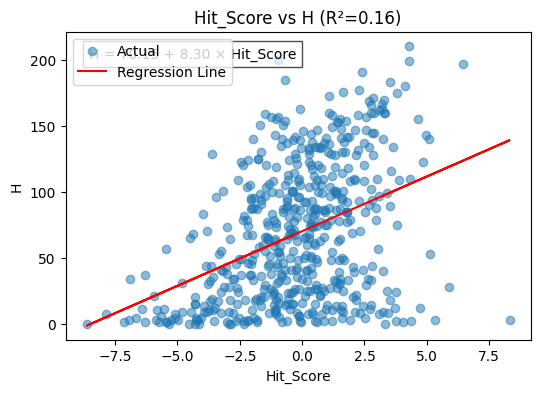

Linear Regression for Walk_Score vs BB:
  Equation: BB = 22.550 + -7.280 * Walk_Score
  R^2 Score: 0.0653



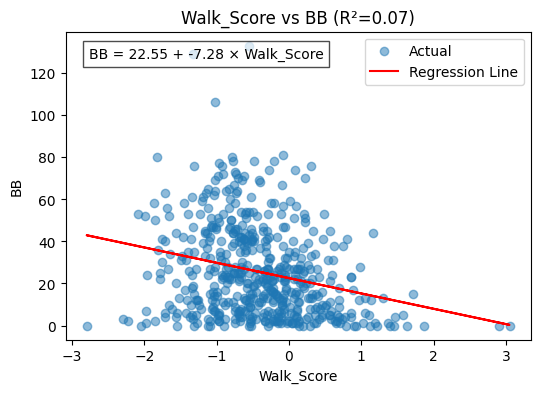

Linear Regression for Bats_Score vs AB:
  Equation: AB = 2384.413 + 9054.435 * Bats_Score
  R^2 Score: 0.2443



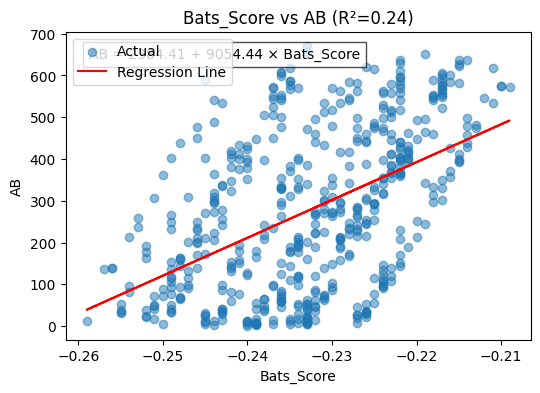

Linear Regression for Bases_Score vs TB:
  Equation: TB = 113.671 + 11.312 * Bases_Score
  R^2 Score: 0.1878



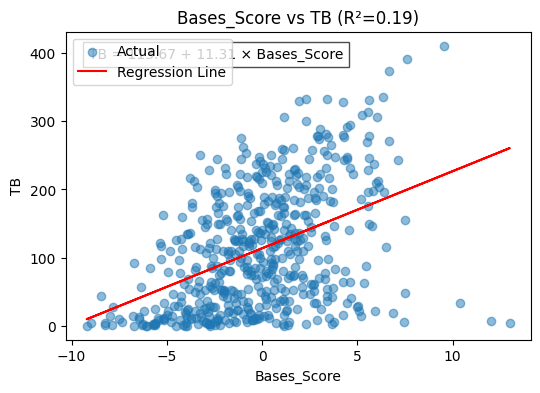

In [ ]:
# 7 Data Science for the equations
for score_col, real_col in score_stat_pairs:
    # Drop missing values for this pair
    subset = df_merged[[score_col, real_col]].dropna()
    X = subset[[score_col]].values
    y = subset[real_col].values

    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    coef = model.coef_[0]
    intercept = model.intercept_

    # Print the equation
    print(f"Linear Regression for {score_col} vs {real_col}:")
    print(f"  Equation: {real_col} = {intercept:.3f} + {coef:.3f} * {score_col}")
    print(f"  R^2 Score: {r2:.4f}\n")

    # Plot
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, alpha=0.5, label='Actual')
    plt.plot(X, y_pred, color='red', label='Regression Line')
    plt.xlabel(score_col)
    plt.ylabel(real_col)
    plt.title(f"{score_col} vs {real_col} (R²={r2:.2f})")
    # Show equation on plot
    eq_text = f"{real_col} = {intercept:.2f} + {coef:.2f} × {score_col}"
    plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))
    plt.legend()
    plt.show()
